In [20]:
# (1) Paths and configuration
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

IN_2019_DIR = "../data/safegraph/DailyMobility/2019"
AGE_CSV = "../data/census2020_cbg.csv"

OUT_ROOT = "../results/f1a_near"
OUT_2019 = os.path.join(OUT_ROOT, "2019")
OUT_CSV = os.path.join(OUT_ROOT, "csv")

LOW_CUT = 0.20
HIGH_CUT = 0.50

BOOTSTRAP_N = 2000
RNG_SEED = 42

for d in [OUT_ROOT, OUT_2019, OUT_CSV]:
    os.makedirs(d, exist_ok=True)

print("IN_2019_DIR:", IN_2019_DIR)
print("AGE_CSV:", AGE_CSV)
print("OUT_2019:", OUT_2019)
print("OUT_CSV:", OUT_CSV)

IN_2019_DIR: ../data/safegraph/DailyMobility/2019
AGE_CSV: ../data/census2020_cbg.csv
OUT_2019: ../results/f1a_near/2019
OUT_CSV: ../results/f1a_near/csv


In [21]:
# (2) Load CBG age data
age_df = (
    pd.read_csv(AGE_CSV)
    .assign(
        GEOID=lambda d: d["GEOID"].astype(str).str.zfill(12),
        prop_65plus=lambda d: pd.to_numeric(d["prop_65plus"], errors="coerce"),
    )
    .loc[:, ["GEOID", "prop_65plus"]]
    .dropna(subset=["prop_65plus"])
    .reset_index(drop=True)
 )

age_df.head()

,GEOID,prop_65plus
0,010830209002,0.201667
1,010830208061,0.174480
2,010830208062,0.197333
3,010830209001,0.233053
4,010830210001,0.178100


In [22]:
# (3) Helpers and cache
LOW_LABEL = "Less than 20%"
HIGH_LABEL = "More than 50%"
AGE_LABELS = [LOW_LABEL, HIGH_LABEL]

CACHE_2TYPE = os.path.join(OUT_ROOT, "cache_2019_2type.parquet")
CACHE_2TYPE_IDS = os.path.join(OUT_ROOT, "cache_2019_2type_ids.parquet")

SEASON_COLORS = {
    "Spring": {LOW_LABEL: "#F6E7A1", HIGH_LABEL: "#F7D651"},
    "Summer": {LOW_LABEL: "#F59A9C", HIGH_LABEL: "#E16164"},
    "Autumn": {LOW_LABEL: "#F5C18B", HIGH_LABEL: "#F89C5B"},
    "Winter": {LOW_LABEL: "#9FC7DB", HIGH_LABEL: "#4E9FD0"},
}

def make_age_group(p):
    if pd.isna(p):
        return np.nan
    if p <= LOW_CUT:
        return LOW_LABEL
    if p >= HIGH_CUT:
        return HIGH_LABEL
    return np.nan

def prep_month(csv_path):
    raw = (
        pd.read_csv(csv_path)
        .assign(
            origin_census_block_group=lambda d: d["origin_census_block_group"].astype(str).str.zfill(12),
            date=lambda d: pd.to_datetime(d["date"]).dt.date,
        )
        .merge(age_df, left_on="origin_census_block_group", right_on="GEOID", how="left")
        .dropna(subset=["prop_65plus"])
    )
    raw["group"] = raw["prop_65plus"].apply(make_age_group)
    raw = raw.dropna(subset=["group"])

    daily = raw.groupby(["date", "group"], as_index=False)["p_1_1000"].mean()
    ids = raw.loc[:, ["group", "origin_census_block_group"]].drop_duplicates()
    return daily, ids

def load_or_build_cache_2type(in_dir):
    if os.path.exists(CACHE_2TYPE) and os.path.exists(CACHE_2TYPE_IDS):
        df_all = pd.read_parquet(CACHE_2TYPE)
        ids_all = pd.read_parquet(CACHE_2TYPE_IDS)
        return df_all, ids_all

    all_daily = []
    all_ids = []
    for m in range(1, 13):
        mm = f"{m:02d}"
        basename = os.path.basename(in_dir.rstrip("/"))
        fname = f"CBG_daily_{basename}_{mm}_refined.csv"
        fpath = os.path.join(in_dir, fname)
        if not os.path.exists(fpath):
            print("Skip:", fpath)
            continue
        df_daily, ids = prep_month(fpath)
        all_daily.append(df_daily)
        all_ids.append(ids)

    if len(all_daily) == 0:
        return None, None

    df_all = pd.concat(all_daily, ignore_index=True)
    ids_all = pd.concat(all_ids, ignore_index=True).drop_duplicates()
    try:
        df_all.to_parquet(CACHE_2TYPE, index=False)
        ids_all.to_parquet(CACHE_2TYPE_IDS, index=False)
    except Exception as e:
        print("Cache write skipped:", e)
    return df_all, ids_all

def cohens_d_bootstrap(x, y, n_boot=BOOTSTRAP_N, seed=RNG_SEED):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    x = x[~np.isnan(x)]
    y = y[~np.isnan(y)]
    nx, ny = len(x), len(y)
    if nx < 2 or ny < 2:
        return np.nan, np.nan, np.nan

    def _cohen_d(a, b):
        nx_, ny_ = len(a), len(b)
        varx = np.var(a, ddof=1)
        vary = np.var(b, ddof=1)
        pooled = np.sqrt(((nx_ - 1) * varx + (ny_ - 1) * vary) / (nx_ + ny_ - 2))
        if pooled == 0:
            return np.nan
        return (np.mean(a) - np.mean(b)) / pooled

    d_hat = _cohen_d(x, y)
    rng = np.random.default_rng(seed)
    boots = []
    for _ in range(n_boot):
        xb = rng.choice(x, size=nx, replace=True)
        yb = rng.choice(y, size=ny, replace=True)
        boots.append(_cohen_d(xb, yb))
    boots = np.array(boots, dtype=float)
    lo, hi = np.nanpercentile(boots, [2.5, 97.5])
    return d_hat, lo, hi

def _season_from_month(m: int) -> str:
    if m in (12, 1, 2):
        return "Winter"
    if m in (3, 4, 5):
        return "Spring"
    if m in (6, 7, 8):
        return "Summer"
    return "Autumn"

def _sig_star(p):
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return ""

def _calc_stats(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    x = x[~np.isnan(x)]
    y = y[~np.isnan(y)]
    if len(x) < 2 or len(y) < 2:
        return None
    mean_low = float(np.nanmean(x))
    mean_high = float(np.nanmean(y))
    mean_diff = mean_high - mean_low
    t_stat, p_val = stats.ttest_ind(x, y, equal_var=False, nan_policy="omit")
    d_hat, ci_low, ci_high = cohens_d_bootstrap(x, y)
    return {
        "mean_low": mean_low,
        "mean_high": mean_high,
        "mean_diff": mean_diff,
        "t_stat": float(t_stat),
        "p_value": float(p_val),
        "cohen_d": float(d_hat),
        "ci_low": float(ci_low),
        "ci_high": float(ci_high),
    }

def _print_sig_table(rows, title):
    if not rows:
        return None
    df = pd.DataFrame(rows)
    df_display = df.copy()
    for col in ["mean_low", "mean_high", "mean_diff", "t_stat", "p_value", "cohen_d", "ci_low", "ci_high"]:
        if col in df_display.columns:
            df_display[col] = df_display[col].map(lambda v: f"{v:.4f}" if pd.notna(v) else "nan")
    print(f"\n=== {title} ===")
    print(df_display.to_string(index=False))
    return df

In [23]:
# (4) Yearly processing helpers
def build_yearly_summary(in_dir, year_lab="2019"):
    df_all, ids_all = load_or_build_cache_2type(in_dir)
    if df_all is None or ids_all is None:
        print("No monthly files found.")
        return None, None, None, None, None

    n_tbl_year = (
        ids_all.groupby("group", as_index=False)
        .size()
        .rename(columns={"size": "n_cbg"})
    )
    n_tbl_year["group"] = pd.Categorical(n_tbl_year["group"], categories=AGE_LABELS, ordered=True)
    print("Group counts (CBGs):")
    print(n_tbl_year.to_string(index=False))

    df_all_export = df_all.sort_values(["date", "group"]).copy()

    stats_row = None
    if df_all["group"].nunique() == 2:
        g1 = df_all.loc[df_all["group"] == AGE_LABELS[0], "p_1_1000"]
        g2 = df_all.loc[df_all["group"] == AGE_LABELS[1], "p_1_1000"]
        stats_row = _calc_stats(g1, g2)
        if stats_row:
            stats_row = {"period": year_lab, **stats_row}
            _print_sig_table([stats_row], title=f"{year_lab} significance")

    return df_all, ids_all, n_tbl_year, df_all_export, stats_row

In [24]:
# (5) Yearly data processing
df_all, ids_all, n_tbl_year, df_all_export, stats_row = build_yearly_summary(IN_2019_DIR, year_lab="2019")

Cache write skipped: Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - Missing optional dependency 'pyarrow'. pyarrow is required for parquet support. Use pip or conda to install pyarrow.
 - Missing optional dependency 'fastparquet'. fastparquet is required for parquet support. Use pip or conda to install fastparquet.
Group counts (CBGs):
        group  n_cbg
Less than 20% 113515
More than 50%   1498

=== 2019 significance ===
period mean_low mean_high mean_diff  t_stat p_value cohen_d  ci_low ci_high
  2019   0.1431    0.1499    0.0068 -6.6002  0.0000 -0.4892 -0.6459 -0.3370


In [32]:
# (5c) Group summary stats (mean/std/min/max)
if df_all is not None:
    df_sum = df_all.copy()
    df_sum["group"] = pd.Categorical(df_sum["group"], categories=AGE_LABELS, ordered=True)
    summary = (
        df_sum.groupby("group")["p_1_1000"]
        .agg(n="size", mean="mean", std="std", min_val="min", max_val="max")
        .reset_index()
    )
    print(summary.to_string(index=False))

        group   n     mean      std  min_val  max_val
Less than 20% 364 0.143118 0.013733 0.113735 0.192327
More than 50% 364 0.149928 0.014104 0.122409 0.189196


/var/folders/70/9hqvlqrx7xl5xc39jc4d20y00000gn/T/ipykernel_47894/4219916325.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_sum.groupby("group")["p_1_1000"]


In [26]:
# (6) Export yearly outputs
if df_all is not None:
    n_out = os.path.join(OUT_CSV, "near_2019_n.csv")
    n_tbl_year.to_csv(n_out, index=False)
    print("Saved:", n_out)

    out_csv = os.path.join(OUT_CSV, "near_2019.csv")
    df_all_export.to_csv(out_csv, index=False)
    print("Exported yearly daily summary:", out_csv)

    if stats_row:
        stats_out = os.path.join(OUT_CSV, "t_stats_2019.csv")
        pd.DataFrame([stats_row]).to_csv(stats_out, index=False)
        print("Saved:", stats_out)

Saved: ../results/f1a_near/csv/near_2019_n.csv
Exported yearly daily summary: ../results/f1a_near/csv/near_2019.csv
Saved: ../results/f1a_near/csv/t_stats_2019.csv


In [201]:
# (7) Yearly plot function
def plot_yearly_box_2type(df_all, outfile, stats_row=None):
    df = df_all.copy()
    df["group"] = pd.Categorical(df["group"], categories=AGE_LABELS, ordered=True)
    vals_low = df.loc[df["group"] == AGE_LABELS[0], "p_1_1000"].dropna().values
    vals_high = df.loc[df["group"] == AGE_LABELS[1], "p_1_1000"].dropna().values

    fig, ax = plt.subplots(figsize=(8 / 2.54, 7 / 2.54), dpi=600)
    data = [vals_low, vals_high]
    positions = [1.35, 1.75]
    vp = ax.violinplot(
        data,
        positions=positions,
        widths=0.35,
        showmeans=False,
        showmedians=False,
        showextrema=False,
    )
    # colors = ["#FAD5DC", "#E6D0E5"]
    colors = ["#E6D0E5", "#FAD5DC"] 
    for body, col in zip(vp["bodies"], colors):
        body.set_facecolor(col)
        body.set_edgecolor("black")
        body.set_linewidth(0.3)
        body.set_alpha(1.0)

    for i, vals in enumerate([vals_low, vals_high]):
        if len(vals) == 0:
            continue
        q1, q3 = np.nanpercentile(vals, [25, 75])
        mean = float(np.nanmean(vals))
        ci_low, ci_high = np.nanpercentile(vals, [2.5, 97.5])
        ax.vlines(positions[i], ci_low, ci_high, color="#444444", linewidth=0.8, zorder=3)
        ax.vlines(positions[i], q1, q3, color="#444444", linewidth=2.0, zorder=4)
        ax.scatter([positions[i]], [mean], color="white", s=2, zorder=5)

    # scatter_colors = ["#F1A0AE", "#B886B9"]
    scatter_colors = ["#B886B9", "#F1A0AE"]
    rng = np.random.default_rng(RNG_SEED)
    jitter = 0.03
    for i, vals in enumerate([vals_low, vals_high]):
        if len(vals) == 0:
            continue
        x = positions[i] + rng.uniform(-jitter, jitter, size=len(vals))
        ax.scatter(
            x,
            vals,
            s=4,
            alpha=1,
            color=scatter_colors[i],
            edgecolors="grey",
            zorder=2,
            linewidths=0.2,
        )

    ax.set_xlim(1.0, 2.1)
    ax.set_xticks(positions)
    ax.set_xticklabels(["Less than 20%", "More than 50%"], fontsize=7)
    ax.tick_params(axis="x", which="major", pad=2, length=2, width=0.3)
    ax.set_xlabel("Residents Aged 65+ (% of Population, U.S. CBGs)", fontsize=7, labelpad=7)
    ax.set_ylabel("Percentage of community mobility (%)", fontsize=7)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y * 100:.0f}"))
    ax.tick_params(axis="y", labelsize=7, width=0.3)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.3)
    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)
    ax.grid(False)

    y_vals = df["p_1_1000"].dropna().values
    y_min = float(np.nanmin(y_vals)) if len(y_vals) else 0.0
    y_max = float(np.nanmax(y_vals)) if len(y_vals) else 0.0
    y_range = max(y_max - y_min, 0.05)
    y_star = y_max + 0.05 * y_range

    stats_use = stats_row or _calc_stats(vals_low, vals_high)
    if stats_use:
        p_val = stats_use["p_value"]
        if p_val < 0.001:
            sig_label = "p<0.001"
        elif p_val < 0.01:
            sig_label = "p<0.01"
        elif p_val < 0.05:
            sig_label = "p<0.05"
        else:
            sig_label = ""
        if sig_label:
            x1, x2 = positions
            ax.plot([x1, x1, x2, x2], [y_star, y_star + 0.02 * y_range, y_star + 0.02 * y_range, y_star], color="black", linewidth=0.3)
            ax.text((x1 + x2) / 2, y_star + 0.025 * y_range, sig_label, ha="center", va="bottom", fontsize=7)

    ax.set_ylim(bottom=y_min - 0.12 * y_range, top=y_star + 0.18 * y_range)

    plt.tight_layout()
    fig.savefig(outfile, dpi=600)
    plt.show()
    plt.close(fig)
    print("Saved:", outfile)
    return stats_use

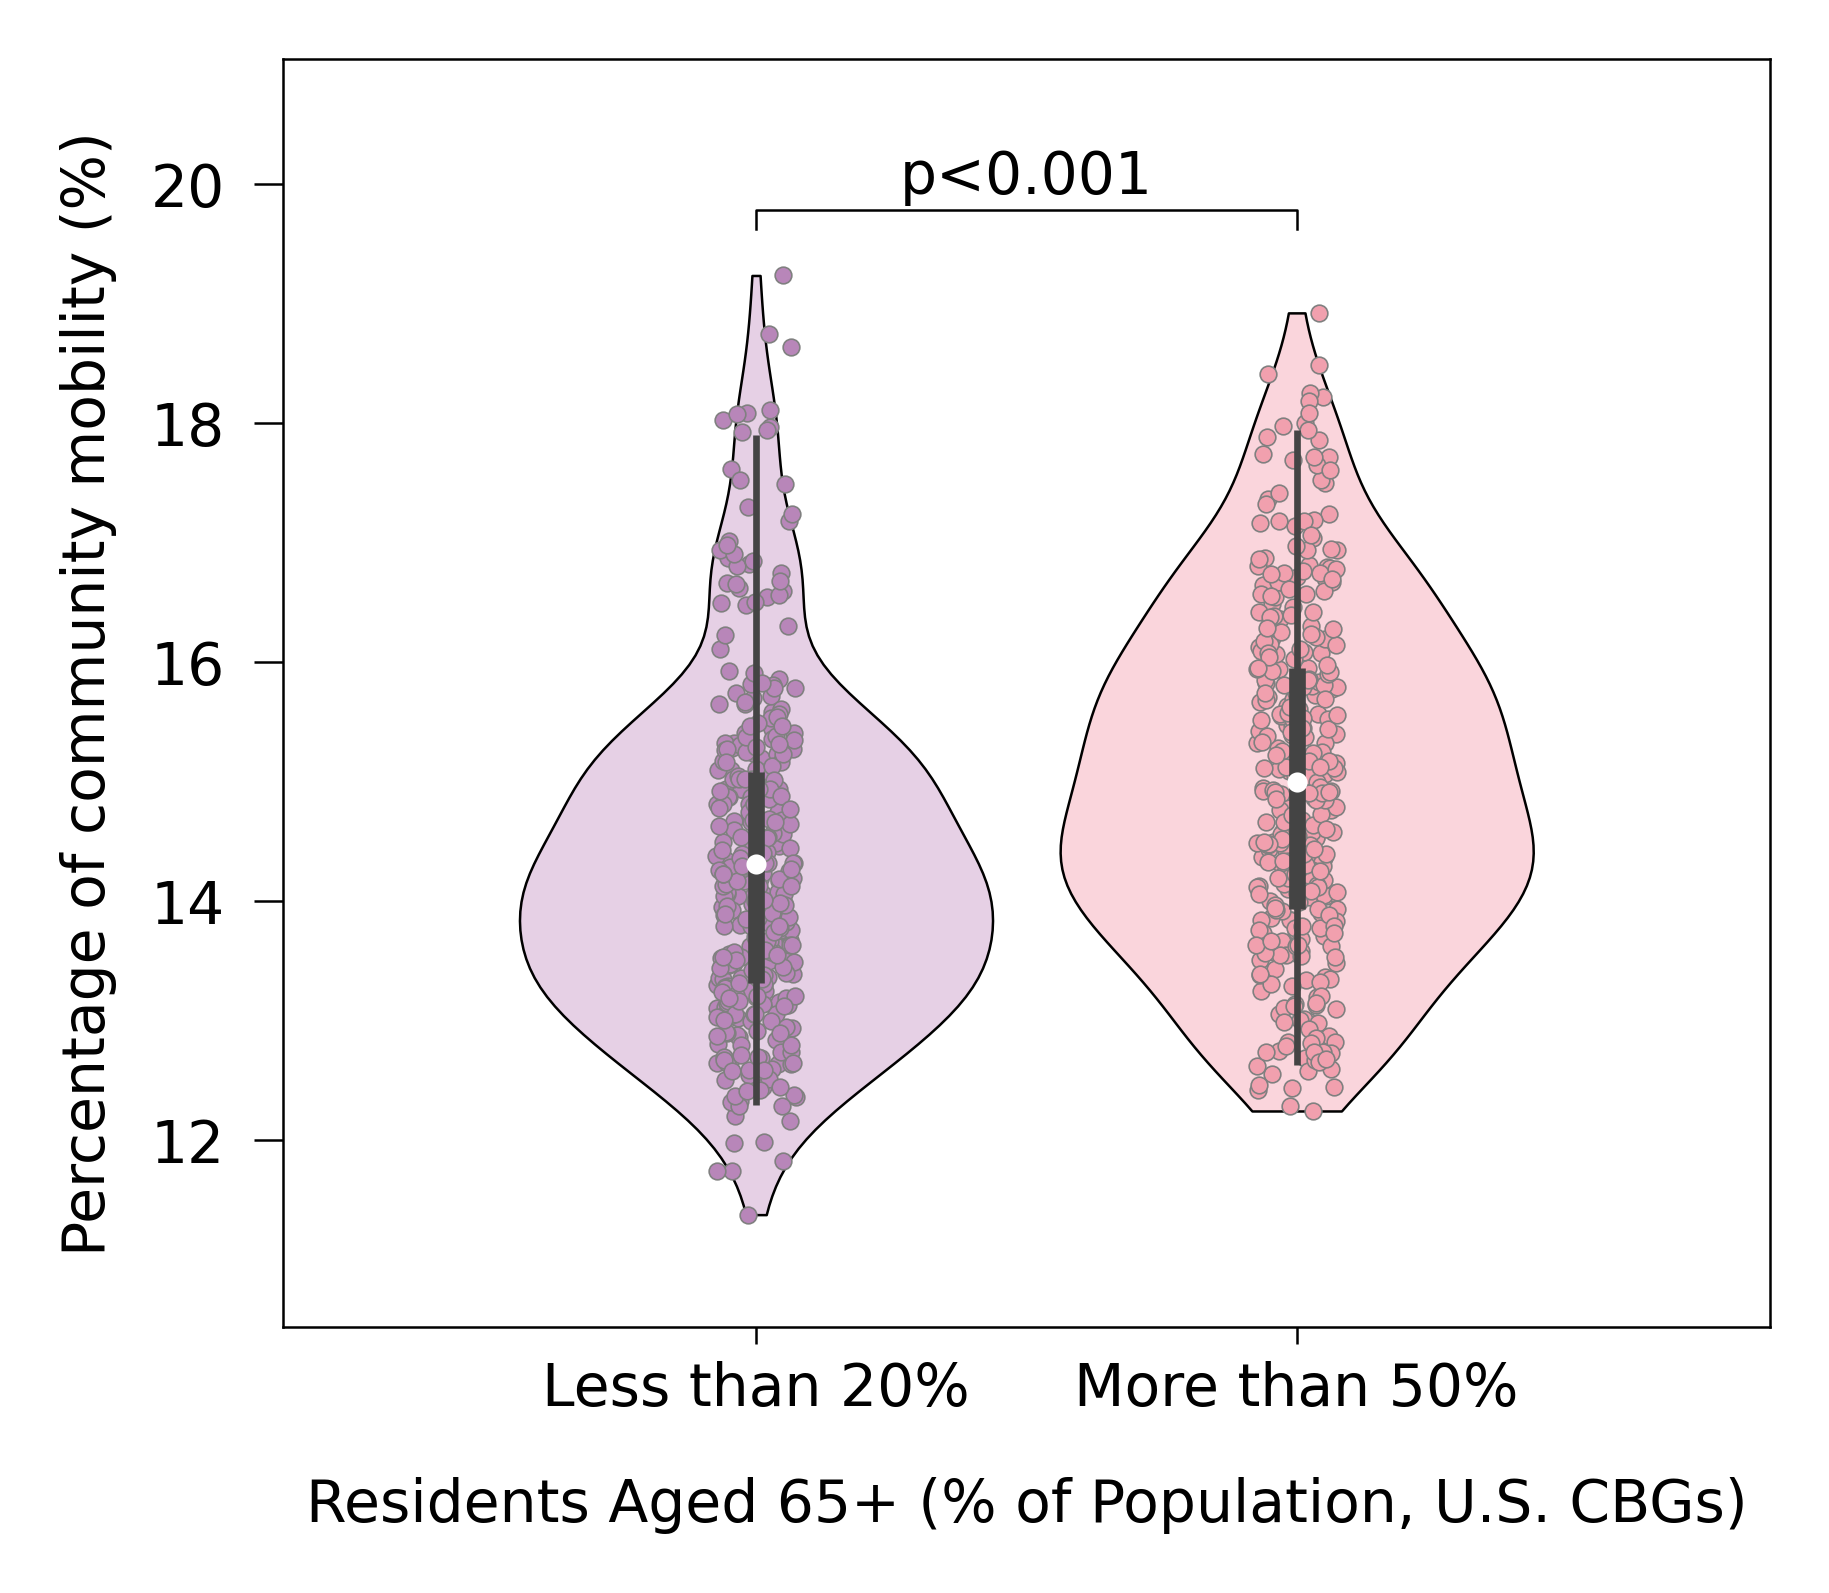

Saved: ../results/f1a_near/2019/2019_all_violin_p_1_1000.pdf


In [202]:
# (8) Plot yearly outputs
if df_all is not None:
    out_year = os.path.join(OUT_2019, "2019_all_violin_p_1_1000.pdf")
    _ = plot_yearly_box_2type(df_all, out_year, stats_row=stats_row)

In [30]:
# (9) Seasonal plot function
def plot_seasonal_box_2type(in_dir, out_dir_year, year_lab="2019"):
    df_all, ids_all = load_or_build_cache_2type(in_dir)
    if df_all is None or ids_all is None:
        print("No monthly files found.")
        return None
    df = df_all.copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df = df.dropna(subset=["date", "group"])
    df["month"] = df["date"].dt.month
    df["season"] = df["month"].apply(_season_from_month)
    season_order = ["Spring", "Summer", "Autumn", "Winter"]
    season_labels = ["Mar, Apr, May", "Jun, Jul, Aug", "Sep, Oct, Nov", "Dec, Jan, Feb"]
    df["season"] = pd.Categorical(df["season"], categories=season_order, ordered=True)
    df["group"] = pd.Categorical(df["group"], categories=AGE_LABELS, ordered=True)

    group_counts = (
        ids_all.groupby("group", as_index=False)
        .size()
        .rename(columns={"size": "n_cbg"})
    )
    group_counts["group"] = pd.Categorical(group_counts["group"], categories=AGE_LABELS, ordered=True)
    print("Group counts (CBGs):")
    print(group_counts.to_string(index=False))

    fig, ax = plt.subplots(figsize=(11 / 2.54, 7 / 2.54), dpi=600)
    data = []
    positions = []
    colors = []
    pos = 1
    gap = 1.0
    offsets = [-0.18, 0.18]
    for season in season_order:
        for i, grp in enumerate(AGE_LABELS):
            vals = df.loc[(df["season"] == season) & (df["group"] == grp), "p_1_1000"].dropna().values
            data.append(vals)
            positions.append(pos + offsets[i])
            colors.append(SEASON_COLORS[season][grp])
        pos += gap

    bp = ax.boxplot(
        data,
        positions=positions,
        widths=0.28,
        patch_artist=True,
        showfliers=False,
    )
    for patch, col in zip(bp["boxes"], colors):
        patch.set_facecolor(col)
        patch.set_edgecolor("black")
        patch.set_linewidth(0.3)
    for key in ["whiskers", "caps", "medians"]:
        for line in bp[key]:
            line.set_color("black")
            line.set_linewidth(0.3)

    ax.set_xticks(positions)
    ax.set_xticklabels(["≤20", "≥50"] * len(season_order), fontsize=7)
    ax.tick_params(axis="x", which="major", pad=2, length=2, width=0.3)
    secax = ax.secondary_xaxis("top")
    secax.set_xticks([1, 2, 3, 4])
    secax.set_xticklabels(season_labels, fontsize=7)
    secax.tick_params(axis="x", which="major", pad=2, length=0, width=0.3)
    secax.spines["top"].set_linewidth(0.3)
    ax.set_xlabel("CBG-level proportion aged 65 and older", fontsize=7, labelpad=10)
    ax.set_ylabel("Percentage of community mobility (%)", fontsize=7)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y * 100:.0f}"))
    ax.tick_params(axis="y", labelsize=7, width=0.3)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.3)
    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)
    ax.grid(False)

    y_vals = df["p_1_1000"].dropna().values
    y_min = float(np.nanmin(y_vals)) if len(y_vals) else 0.0
    y_max = float(np.nanmax(y_vals)) if len(y_vals) else 0.0
    y_range = max(y_max - y_min, 0.05)
    y_star = y_max + 0.05 * y_range

    sig_rows = []
    for i, season in enumerate(season_order, start=1):
        x1 = i + offsets[0]
        x2 = i + offsets[1]
        v1 = df.loc[(df["season"] == season) & (df["group"] == AGE_LABELS[0]), "p_1_1000"].dropna()
        v2 = df.loc[(df["season"] == season) & (df["group"] == AGE_LABELS[1]), "p_1_1000"].dropna()
        stats_row = _calc_stats(v1, v2)
        if stats_row:
            sig_rows.append({"period": season, **stats_row})
            star = _sig_star(stats_row["p_value"])
            if star:
                ax.plot([x1, x1, x2, x2], [y_star, y_star + 0.02 * y_range, y_star + 0.02 * y_range, y_star], color="black", linewidth=0.3)
                ax.text((x1 + x2) / 2, y_star + 0.025 * y_range, star, ha="center", va="bottom", fontsize=7, fontweight="bold")

    if sig_rows:
        sig_df = _print_sig_table(sig_rows, title="Seasonal significance")
        if sig_df is not None:
            sig_out = os.path.join(OUT_CSV, f"t_stats_{year_lab}_season.csv")
            sig_df.to_csv(sig_out, index=False)
            print("Saved:", sig_out)

    ax.set_ylim(bottom=y_min - 0.12 * y_range, top=y_star + 0.18 * y_range)

    plt.tight_layout()
    out_fig = os.path.join(out_dir_year, f"{year_lab}_season_box_p_1_1000.pdf")
    fig.savefig(out_fig, dpi=600)
    plt.show()
    plt.close(fig)
    print("Saved:", out_fig)
    return sig_rows

Cache write skipped: Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - Missing optional dependency 'pyarrow'. pyarrow is required for parquet support. Use pip or conda to install pyarrow.
 - Missing optional dependency 'fastparquet'. fastparquet is required for parquet support. Use pip or conda to install fastparquet.
Group counts (CBGs):
        group  n_cbg
Less than 20% 113515
More than 50%   1498

=== Seasonal significance ===
period mean_low mean_high mean_diff  t_stat p_value cohen_d  ci_low ci_high
Spring   0.1480    0.1558    0.0078 -4.2354  0.0000 -0.6245 -0.9536 -0.3357
Summer   0.1331    0.1408    0.0077 -5.3657  0.0000 -0.7911 -1.1373 -0.5067
Autumn   0.1402    0.1448    0.0046 -2.6147  0.0097 -0.3876 -0.7118 -0.1119
Winter   0.1514    0.1585    0.0071 -3.5541  0.0005 -0.5328 -0.8644 -0.2368
Saved: ../results/f1a_near/csv

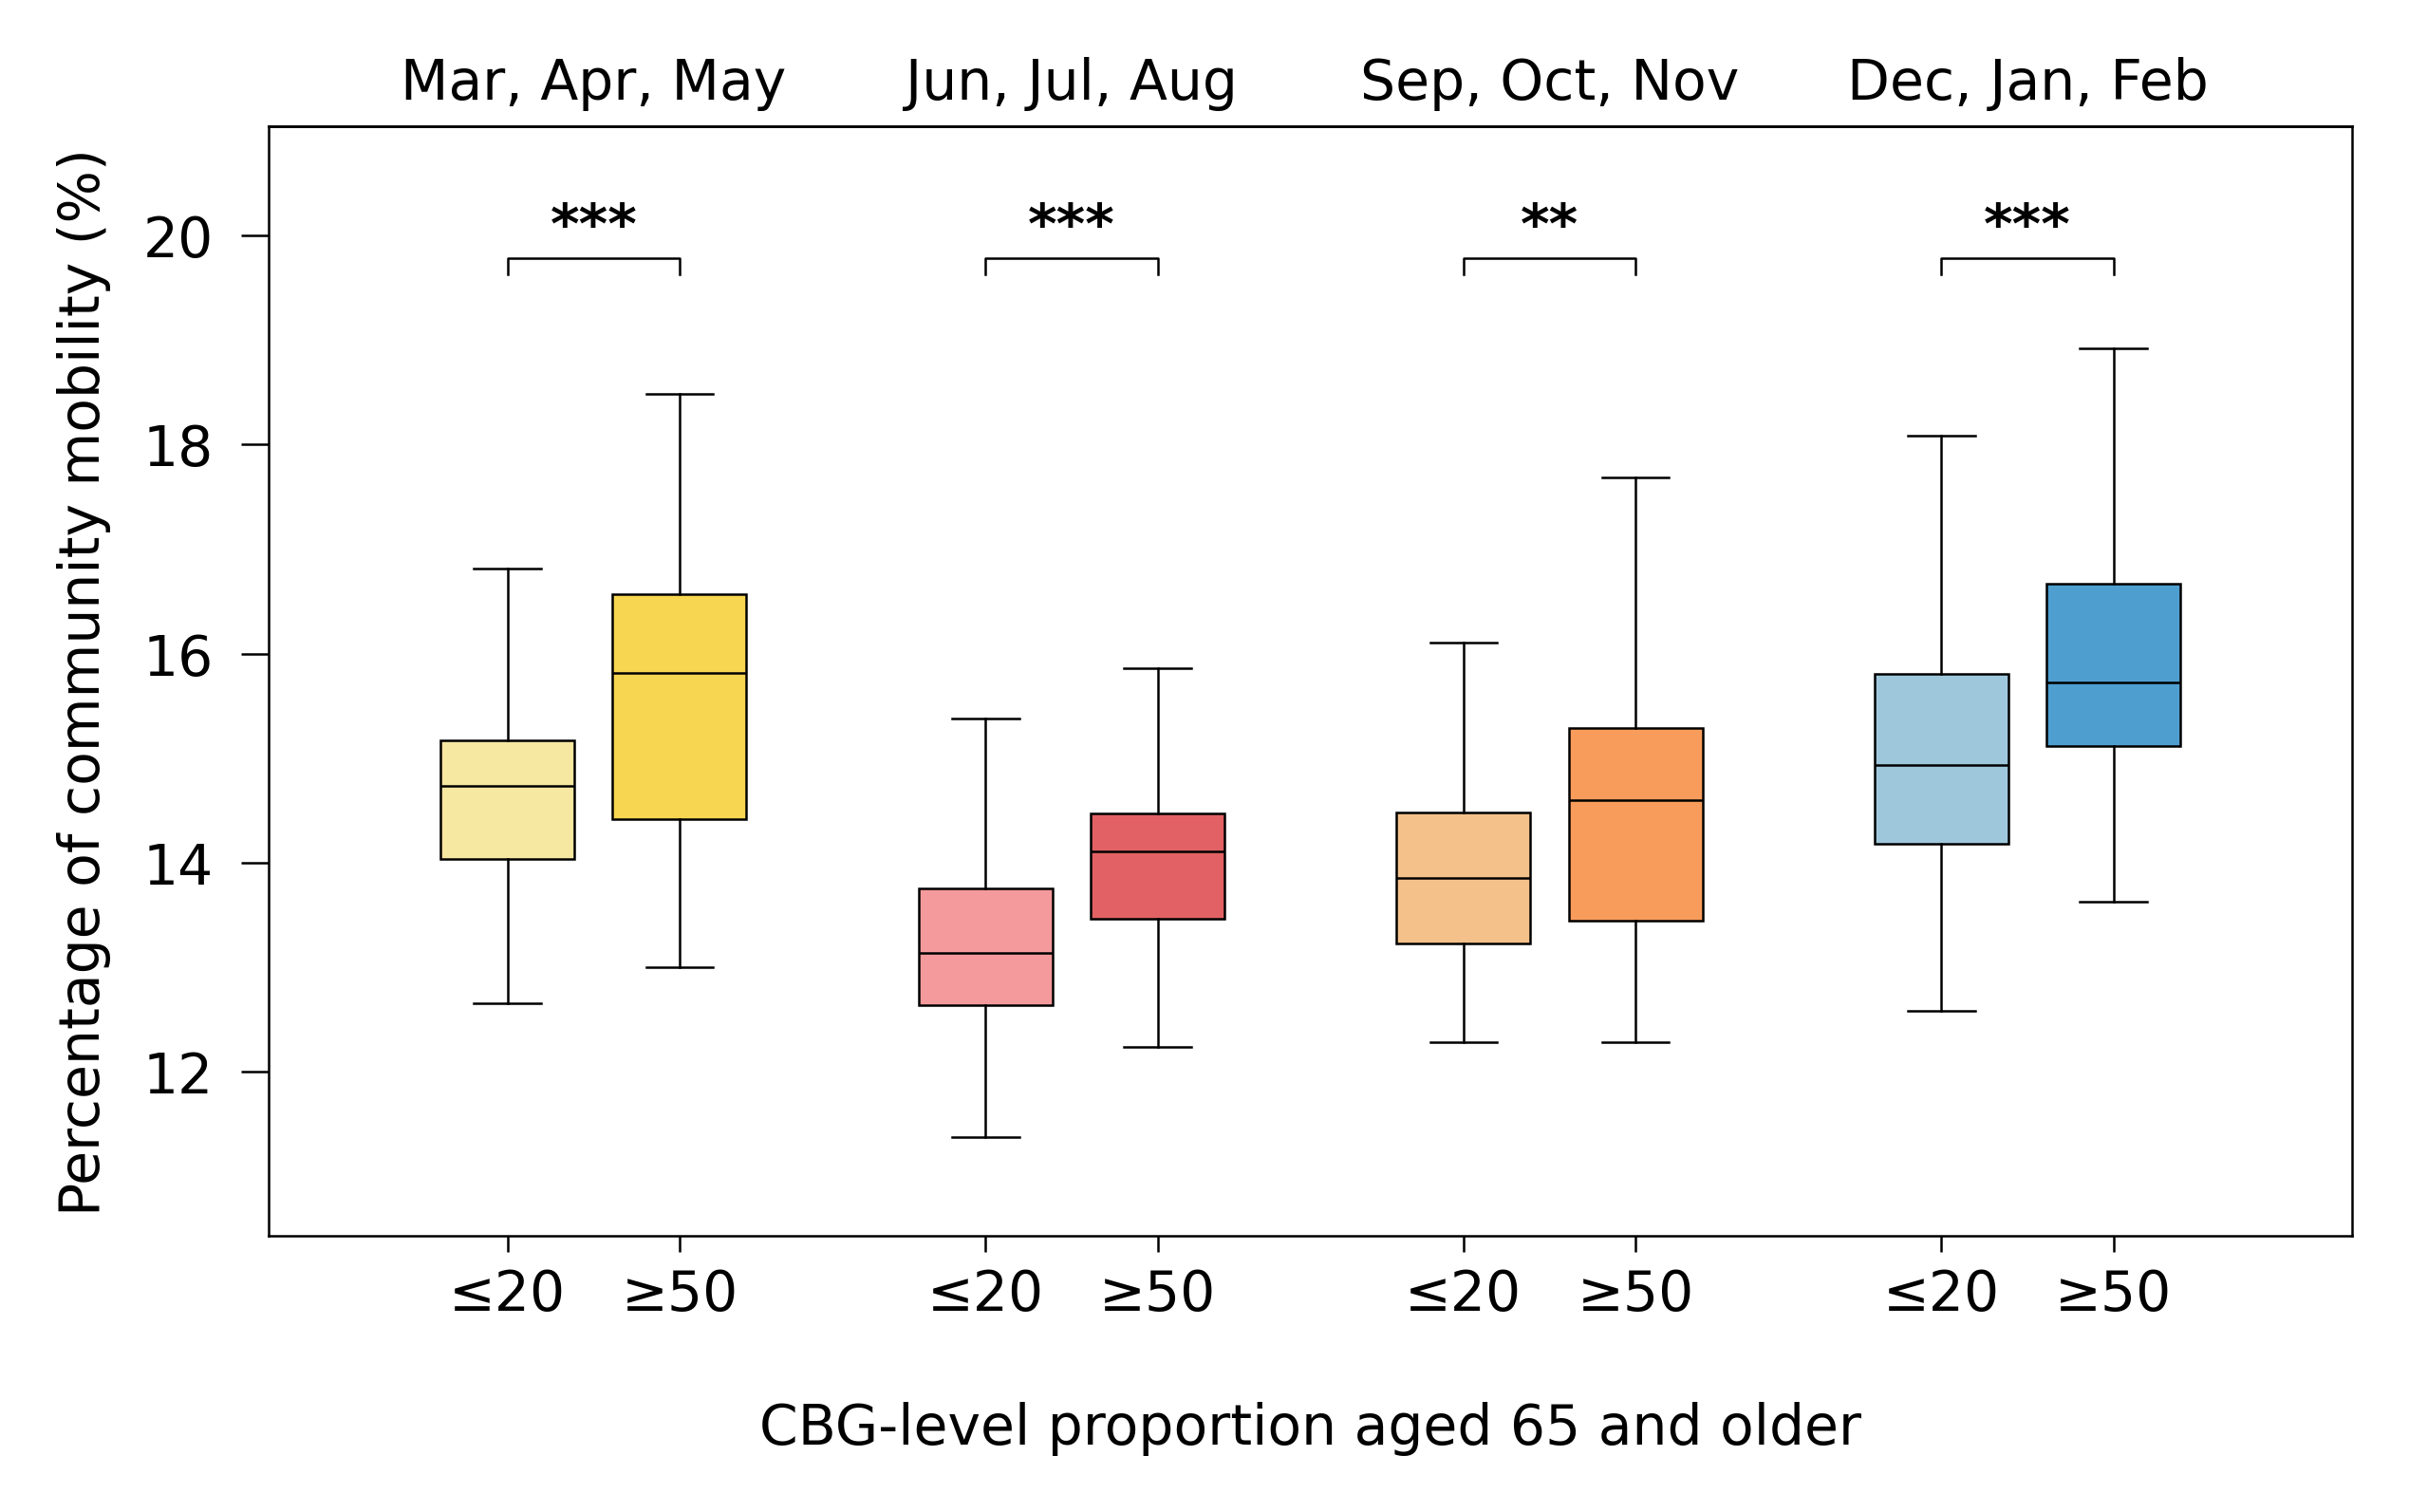

Saved: ../results/f1a_near/2019/2019_season_box_p_1_1000.pdf


In [31]:
# (10) Plot seasonal outputs
if df_all is not None:
    _ = plot_seasonal_box_2type(IN_2019_DIR, OUT_2019, year_lab="2019")